# Cohort FACTM sanity check on synthetic data

This notebook generates synthetic multi-view data with one diversified cohort,
then trains:
- baseline FACTM (`ZPrior.STD_NORMAL`),
- cohort FACTM (`ZPrior.COHORT`) with non-neutral cohort hyperparameters.

Outputs:
- `cohort_elbo_sequence.csv`
- `cohort_elbo_plot.png`
- `cohort_variance_summary.png`
- `cohort_variance_factor_view_heatmap.png`
- `cohort_latent_correlation_heatmap.png`


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views


In [2]:
# Reproducible synthetic setup
rng = np.random.default_rng(123)

K = 6
max_iter = 40
view_dims = [80, 60, 50, 40]
cohort_names = np.array(["diverse", "c1", "c2", "c3"])
n_per_cohort = [140, 140, 140, 140]

C = len(cohort_names)
N = int(np.sum(n_per_cohort))

# One cohort diversified from the rest (strong mean shift on first factors)
mu_ck = np.zeros((C, K), dtype=float)
mu_ck[0, 0] = 3.0
mu_ck[0, 1] = -2.5
mu_ck[0, 2] = 1.8

sigma_ck = np.ones((C, K), dtype=float)
sigma_ck[0, 0] = 0.7
sigma_ck[0, 1] = 0.7
sigma_ck[0, 2] = 0.8

cohort_codes = np.concatenate([
    np.full(n, c, dtype=int) for c, n in enumerate(n_per_cohort)
])
Z_true = np.zeros((N, K), dtype=float)
start = 0
for c, n in enumerate(n_per_cohort):
    stop = start + n
    Z_true[start:stop] = rng.normal(loc=mu_ck[c], scale=sigma_ck[c], size=(n, K))
    start = stop

# Shuffle rows so cohorts are not contiguous
perm = rng.permutation(N)
cohort_codes = cohort_codes[perm]
Z_true = Z_true[perm]

# Build simple Gaussian views
view_arrays = []
for d in view_dims:
    W = rng.normal(0.0, 1.0 / np.sqrt(K), size=(d, K))
    noise = rng.normal(0.0, 0.6, size=(N, d))
    y = Z_true @ W.T + noise
    y = (y - y.mean(axis=0, keepdims=True)) / (y.std(axis=0, keepdims=True) + 1e-8)
    view_arrays.append(y.astype(float))

views = Views.from_list(view_arrays, cohorts=cohort_codes)
print("N:", views.N)
print("K:", K)
print("View dims:", view_dims)
print("Cohort counts:", dict(zip(cohort_names, np.bincount(cohort_codes, minlength=C))))


N: 560
K: 6
View dims: [80, 60, 50, 40]
Cohort counts: {np.str_('diverse'): np.int64(140), np.str_('c1'): np.int64(140), np.str_('c2'): np.int64(140), np.str_('c3'): np.int64(140)}


In [3]:
simple_cfgs = [
    SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD)
    for _ in range(views.num_simple)
]

baseline_config = ModelConfig(
    simple_view_configs=simple_cfgs,
    structured_view_configs=[],
    z_priors=[ZPrior.STD_NORMAL] * K,
    node_update_factor=1.0,
)

# Non-neutral cohort hyperparameters:
# - high pi on first factors,
# - low E[lambda] (larger delta allowed),
# - higher E[tau] (stronger cohort mean pull).
cohort_config = ModelConfig(
    simple_view_configs=simple_cfgs,
    structured_view_configs=[],
    z_priors=[ZPrior.COHORT] * K,
    node_update_factor=1.0,
    cohort_prior_config=CohortPriorConfig(
        pi=[0.95, 0.95, 0.90, 0.80, 0.70, 0.70],
        a_lambda=0.7,
        b_lambda=2.5,
        a0_tau=5.0,
        b0_tau=1.0,
    ),
)

print("Cohort hyperparams:")
print(cohort_config.cohort_prior_config)


Cohort hyperparams:
CohortPriorConfig(pi=[0.95, 0.95, 0.9, 0.8, 0.7, 0.7], a_lambda=0.7, b_lambda=2.5, a0_tau=5.0, b0_tau=1.0)


In [4]:
t0 = time.time()
model_baseline = FACTModel(views=views, K=K, model_config=baseline_config, seed=0)
model_baseline.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
print("Baseline runtime [s]:", round(time.time() - t0, 2))

t1 = time.time()
model_cohort = FACTModel(views=views, K=K, model_config=cohort_config, seed=0)
model_cohort.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
print("Cohort runtime [s]:", round(time.time() - t1, 2))


Pretraining FA
Fitting model



  0%|                                                                                           | 0/40 [00:00<?, ?it/s]


  2%|██                                                                                 | 1/40 [00:00<00:07,  5.52it/s]


  5%|████▏                                                                              | 2/40 [00:00<00:06,  6.24it/s]


  8%|██████▏                                                                            | 3/40 [00:00<00:05,  6.95it/s]

...


 95%|█████████████████████████████████████████████████████████████████████████████▉    | 38/40 [00:04<00:00,  8.65it/s]


 98%|███████████████████████████████████████████████████████████████████████████████▉  | 39/40 [00:04<00:00,  8.31it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  8.51it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  8.47it/s]

Cohort runtime [s]: 4.85


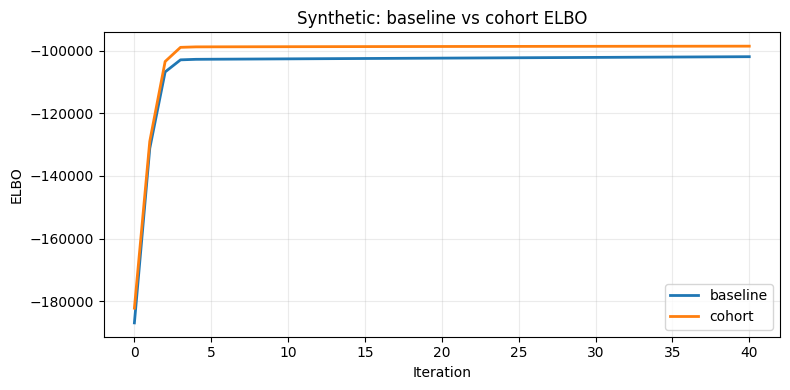

Baseline ELBO first/last: -186876.02896186616 -101946.115549993
Cohort   ELBO first/last: -182175.86504455798 -98588.56489854069


In [5]:
elbo_baseline = np.asarray(model_baseline.elbo_sequence, dtype=float)
elbo_cohort = np.asarray(model_cohort.elbo_sequence, dtype=float)

n = int(max(len(elbo_baseline), len(elbo_cohort)))
baseline_pad = np.full(n, np.nan, dtype=float)
cohort_pad = np.full(n, np.nan, dtype=float)
baseline_pad[: len(elbo_baseline)] = elbo_baseline
cohort_pad[: len(elbo_cohort)] = elbo_cohort

elbo_df = pd.DataFrame(
    {
        "iter": np.arange(n, dtype=int),
        "elbo_baseline": baseline_pad,
        "elbo_cohort": cohort_pad,
    }
)
elbo_df.to_csv("cohort_elbo_sequence.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(elbo_baseline, label="baseline", linewidth=2)
plt.plot(elbo_cohort, label="cohort", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("Synthetic: baseline vs cohort ELBO")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("cohort_elbo_plot.png", dpi=160)
plt.show()

print("Baseline ELBO first/last:", float(elbo_baseline[0]), float(elbo_baseline[-1]))
print("Cohort   ELBO first/last:", float(elbo_cohort[0]), float(elbo_cohort[-1]))


Variance explained per view:
    view  baseline    cohort
0  view0  0.771034  0.771023
1  view1  0.746813  0.746808
2  view2  0.759675  0.759664
3  view3  0.762455  0.762448

Variance explained per factor:
   factor  baseline    cohort
0       0  0.089982  0.089078
1       1  0.264895  0.257433
2       2  0.129688  0.133518
3       3  0.108944  0.109238
4       4  0.090226  0.088904
5       5  0.096186  0.097259


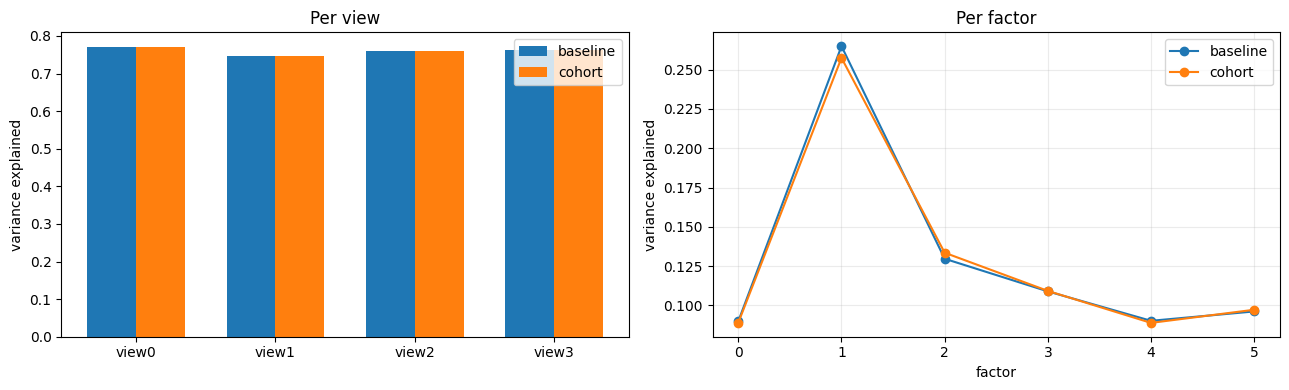

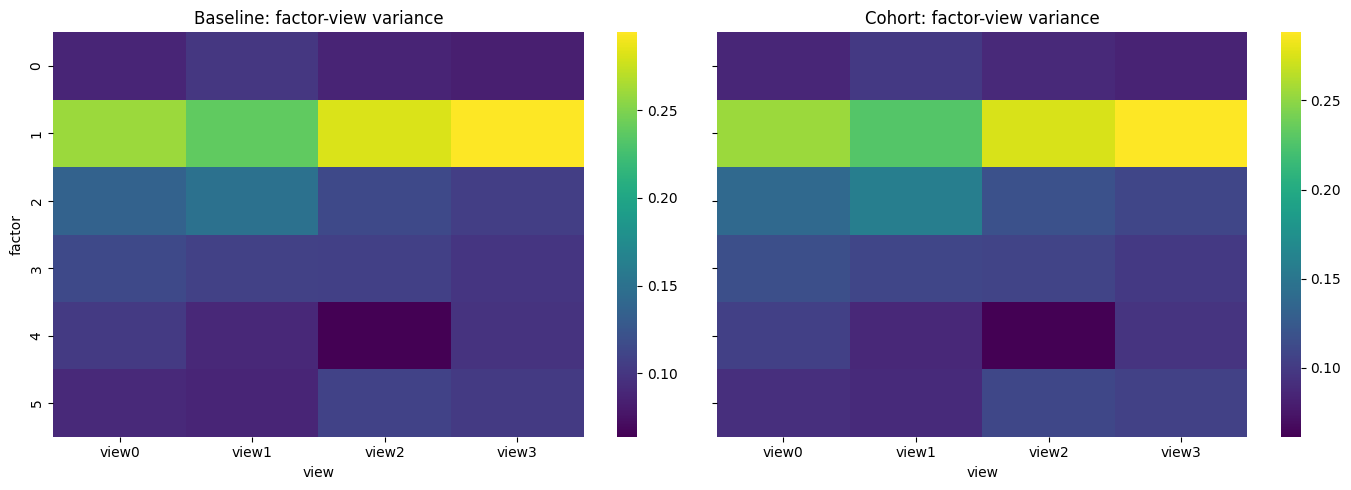

In [6]:
var_view_baseline = np.asarray(model_baseline.fa.variance_explained_per_view(), dtype=float)
var_view_cohort = np.asarray(model_cohort.fa.variance_explained_per_view(), dtype=float)
var_factor_baseline = np.asarray(model_baseline.fa.variance_explained_per_factor(), dtype=float)
var_factor_cohort = np.asarray(model_cohort.fa.variance_explained_per_factor(), dtype=float)
var_factor_view_baseline = np.asarray(model_baseline.fa.variance_explained_per_factor_view(), dtype=float)
var_factor_view_cohort = np.asarray(model_cohort.fa.variance_explained_per_factor_view(), dtype=float)

view_names = [f"view{i}" for i in range(len(view_dims))]

var_view_df = pd.DataFrame(
    {"view": view_names, "baseline": var_view_baseline, "cohort": var_view_cohort}
)
var_factor_df = pd.DataFrame(
    {"factor": np.arange(K, dtype=int), "baseline": var_factor_baseline, "cohort": var_factor_cohort}
)

print("Variance explained per view:")
print(var_view_df)
print("\nVariance explained per factor:")
print(var_factor_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
xv = np.arange(len(view_names), dtype=int)
w = 0.35
axes[0].bar(xv - w / 2, var_view_baseline, width=w, label="baseline")
axes[0].bar(xv + w / 2, var_view_cohort, width=w, label="cohort")
axes[0].set_xticks(xv)
axes[0].set_xticklabels(view_names)
axes[0].set_ylabel("variance explained")
axes[0].set_title("Per view")
axes[0].legend()

xf = np.arange(K, dtype=int)
axes[1].plot(xf, var_factor_baseline, marker="o", label="baseline")
axes[1].plot(xf, var_factor_cohort, marker="o", label="cohort")
axes[1].set_xlabel("factor")
axes[1].set_ylabel("variance explained")
axes[1].set_title("Per factor")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig("cohort_variance_summary.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.heatmap(var_factor_view_baseline, cmap="viridis", ax=axes[0])
axes[0].set_title("Baseline: factor-view variance")
axes[0].set_xlabel("view")
axes[0].set_ylabel("factor")
axes[0].set_xticks(np.arange(len(view_names)) + 0.5)
axes[0].set_xticklabels(view_names)

sns.heatmap(var_factor_view_cohort, cmap="viridis", ax=axes[1])
axes[1].set_title("Cohort: factor-view variance")
axes[1].set_xlabel("view")
axes[1].set_xticks(np.arange(len(view_names)) + 0.5)
axes[1].set_xticklabels(view_names)
plt.tight_layout()
plt.savefig("cohort_variance_factor_view_heatmap.png", dpi=160)
plt.show()


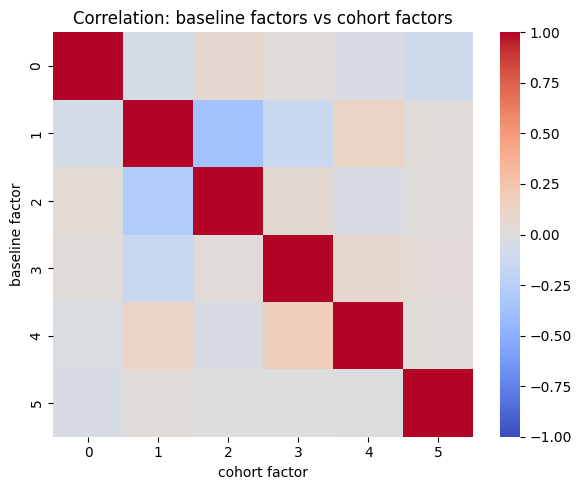

Per-cohort latent means (baseline):
               Z0        Z1        Z2        Z3        Z4        Z5
diverse  0.102604 -0.455614  0.094407  0.099767 -0.062018 -0.000276
c1      -0.046452  0.169612 -0.026895 -0.025049 -0.007333  0.001761
c2      -0.059065  0.156517 -0.022025 -0.035721  0.051802 -0.003635
c3       0.002912  0.129485 -0.045487 -0.038997  0.017549  0.002150

Per-cohort latent means (cohort):
               Z0        Z1        Z2        Z3        Z4        Z5
diverse  0.073988 -0.423382  0.102707  0.087172 -0.056411  0.002340
c1      -0.032745  0.156458 -0.030577 -0.022953 -0.003240  0.000503
c2      -0.040960  0.146387 -0.025699 -0.030168  0.042742 -0.003143
c3      -0.000270  0.120548 -0.046431 -0.034019  0.016871  0.000303


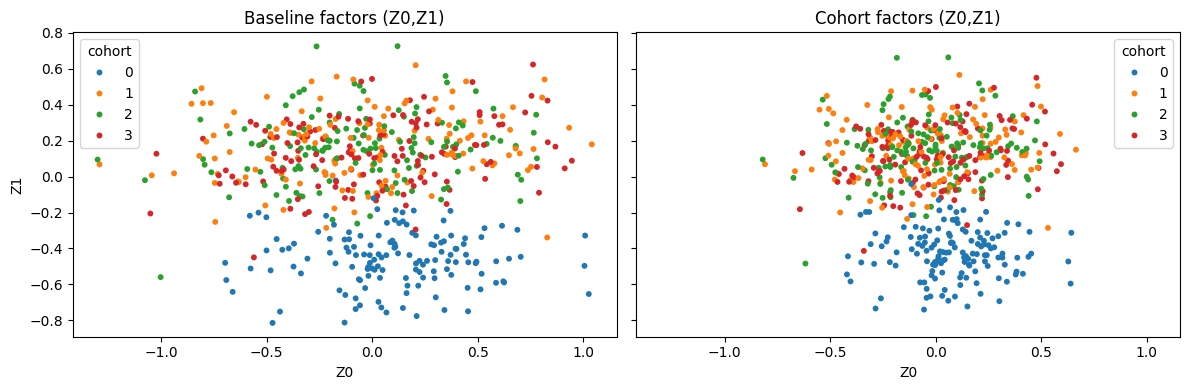

In [7]:
# Factor-space diagnostics: baseline vs cohort + cohort separation
z_baseline = model_baseline.get_latent_factors()
z_cohort = model_cohort.get_latent_factors()

corr_full = np.corrcoef(z_baseline.T, z_cohort.T)
corr_block = corr_full[:K, K:]

plt.figure(figsize=(6, 5))
sns.heatmap(corr_block, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: baseline factors vs cohort factors")
plt.xlabel("cohort factor")
plt.ylabel("baseline factor")
plt.tight_layout()
plt.savefig("cohort_latent_correlation_heatmap.png", dpi=160)
plt.show()

cohort_means_baseline = np.vstack([
    z_baseline[cohort_codes == c].mean(axis=0) for c in range(C)
])
cohort_means_cohort = np.vstack([
    z_cohort[cohort_codes == c].mean(axis=0) for c in range(C)
])

print("Per-cohort latent means (baseline):")
print(pd.DataFrame(cohort_means_baseline, index=cohort_names, columns=[f"Z{k}" for k in range(K)]))
print("\nPer-cohort latent means (cohort):")
print(pd.DataFrame(cohort_means_cohort, index=cohort_names, columns=[f"Z{k}" for k in range(K)]))

if K >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
    sns.scatterplot(x=z_baseline[:, 0], y=z_baseline[:, 1], hue=cohort_codes, palette="tab10", s=18, linewidth=0, ax=axes[0])
    axes[0].set_title("Baseline factors (Z0,Z1)")
    axes[0].set_xlabel("Z0")
    axes[0].set_ylabel("Z1")
    axes[0].legend(title="cohort")

    sns.scatterplot(x=z_cohort[:, 0], y=z_cohort[:, 1], hue=cohort_codes, palette="tab10", s=18, linewidth=0, ax=axes[1])
    axes[1].set_title("Cohort factors (Z0,Z1)")
    axes[1].set_xlabel("Z0")
    axes[1].set_ylabel("Z1")
    axes[1].legend(title="cohort")
    plt.tight_layout()
    plt.show()


In [8]:
# Parameter recovery sanity check (with affine alignment to handle factor indeterminacy)
def affine_align(z_hat: np.ndarray, z_true: np.ndarray):
    x = np.hstack([z_hat, np.ones((z_hat.shape[0], 1))])
    b, *_ = np.linalg.lstsq(x, z_true, rcond=None)
    z_aligned = x @ b
    sse = float(np.sum((z_true - z_aligned) ** 2))
    sst = float(np.sum((z_true - z_true.mean(axis=0, keepdims=True)) ** 2))
    r2 = 1.0 - sse / sst
    return b, z_aligned, r2

b_baseline, z_baseline_aligned, r2_baseline = affine_align(z_baseline, Z_true)
b_cohort, z_cohort_aligned, r2_cohort = affine_align(z_cohort, Z_true)

true_means = np.vstack([Z_true[cohort_codes == c].mean(axis=0) for c in range(C)])
means_baseline_aligned = np.vstack([
    z_baseline_aligned[cohort_codes == c].mean(axis=0) for c in range(C)
])
means_cohort_aligned = np.vstack([
    z_cohort_aligned[cohort_codes == c].mean(axis=0) for c in range(C)
])

mae_baseline = float(np.mean(np.abs(means_baseline_aligned - true_means)))
mae_cohort = float(np.mean(np.abs(means_cohort_aligned - true_means)))
rmse_baseline = float(np.sqrt(np.mean((means_baseline_aligned - true_means) ** 2)))
rmse_cohort = float(np.sqrt(np.mean((means_cohort_aligned - true_means) ** 2)))

# Prior-implied cohort means: E[gamma] * E[delta] per factor, aligned to true space
prior_means_model = np.column_stack([
    p.E_gamma * p.E_delta for p in model_cohort.fa.node_z.z_priors
])
prior_aug = np.hstack([prior_means_model, np.ones((prior_means_model.shape[0], 1))])
prior_means_aligned = prior_aug @ b_cohort
mae_prior = float(np.mean(np.abs(prior_means_aligned - true_means)))
rmse_prior = float(np.sqrt(np.mean((prior_means_aligned - true_means) ** 2)))

recovery_summary = pd.DataFrame(
    {
        "model": ["baseline_z", "cohort_z", "cohort_prior_mean"],
        "R2_vs_true_Z": [r2_baseline, r2_cohort, np.nan],
        "cohort_mean_MAE": [mae_baseline, mae_cohort, mae_prior],
        "cohort_mean_RMSE": [rmse_baseline, rmse_cohort, rmse_prior],
    }
)
recovery_summary.to_csv("cohort_parameter_recovery_summary.csv", index=False)
print(recovery_summary)

print("\nDiverse cohort index (true):", int(np.argmax(np.linalg.norm(true_means, axis=1))))
print("Diverse cohort index (cohort model, aligned):", int(np.argmax(np.linalg.norm(means_cohort_aligned, axis=1))))

means_rows = []
for c, name in enumerate(cohort_names):
    row = {"cohort": str(name)}
    for k in range(K):
        row[f"true_Z{k}"] = float(true_means[c, k])
        row[f"baseline_Z{k}"] = float(means_baseline_aligned[c, k])
        row[f"cohort_Z{k}"] = float(means_cohort_aligned[c, k])
        row[f"cohort_prior_Z{k}"] = float(prior_means_aligned[c, k])
    means_rows.append(row)

pd.DataFrame(means_rows).to_csv("cohort_parameter_recovery_means.csv", index=False)
print("Saved: cohort_parameter_recovery_summary.csv, cohort_parameter_recovery_means.csv")


               model  R2_vs_true_Z  cohort_mean_MAE  cohort_mean_RMSE
0         baseline_z      0.994054         0.005934          0.007706
1           cohort_z      0.994057         0.005882          0.007691
2  cohort_prior_mean           NaN         0.009755          0.012530

Diverse cohort index (true): 0
Diverse cohort index (cohort model, aligned): 0
Saved: cohort_parameter_recovery_summary.csv, cohort_parameter_recovery_means.csv
